# Ml Data Preprocessing file

##Objective
To understand the dataset, clean and preprocess a dataset so that it can be used for ML

##Dataset
Using Diabetes dataset.

The dataset contains information such as:
- Pregnancies
- Glucose
- BloodPressure
- SkinThickness
- Insulin
- BMI
- DiabetesPedigreeFunction
- Age
- Outcome

The target variable is Outcome.

In [38]:
import pandas as pd
import numpy as np

df = pd.read_csv('D:\\AI_Pioneers_INternship\\diabetes.csv')
df.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [39]:
df.shape

(768, 9)

In [40]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    int64  
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB


In [41]:
df.describe()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
count,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000
mean,3.845052,120.894531,69.105469,20.536458,79.799479,31.992578,0.471876,33.240885,0.348958
std,3.369578,31.972618,19.355807,15.952218,115.244002,7.884160,0.331329,11.760232,0.476951
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.078000,21.000000,0.000000
25%,1.000000,99.000000,62.000000,0.000000,0.000000,27.300000,0.243750,24.000000,0.000000
50%,3.000000,117.000000,72.000000,23.000000,30.500000,32.000000,0.372500,29.000000,0.000000
75%,6.000000,140.250000,80.000000,32.000000,127.250000,36.600000,0.626250,41.000000,1.000000
max,17.000000,199.000000,122.000000,99.000000,846.000000,67.100000,2.420000,81.000000,1.000000


In [42]:
df.columns

Index(['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 'Insulin',
       'BMI', 'DiabetesPedigreeFunction', 'Age', 'Outcome'],
      dtype='str')

In [43]:
df['Outcome'].value_counts()

Outcome
0    500
1    268
Name: count, dtype: int64

The datset contains the  zero values in several columns some of them like pregrancies and outcome are possibly zero as a living person can have them. But columns Glucose, BloodPressure, SkinThickness, Insulin, and BMI are treated as potentially missing/invalid measurements as it's not possible for living being to have them zero

In [44]:
(df == 0).sum()

Pregnancies                 111
Glucose                       5
BloodPressure                35
SkinThickness               227
Insulin                     374
BMI                          11
DiabetesPedigreeFunction      0
Age                           0
Outcome                     500
dtype: int64

In [45]:
clean_df = df.copy()

In [46]:
cols_with_invalid_zero = [
    'Glucose',
    'BloodPressure',
    'SkinThickness',
    'Insulin',
    'BMI'
]

clean_df[cols_with_invalid_zero] = clean_df[cols_with_invalid_zero].replace(0, np.nan)

In [47]:
clean_df.isnull().sum()

Pregnancies                   0
Glucose                       5
BloodPressure                35
SkinThickness               227
Insulin                     374
BMI                          11
DiabetesPedigreeFunction      0
Age                           0
Outcome                       0
dtype: int64

In [48]:
(clean_df.isnull().sum() / len(clean_df) * 100).round(2)

Pregnancies                  0.00
Glucose                      0.65
BloodPressure                4.56
SkinThickness               29.56
Insulin                     48.70
BMI                          1.43
DiabetesPedigreeFunction     0.00
Age                          0.00
Outcome                      0.00
dtype: float64

In [49]:
clean_df[cols_with_invalid_zero].describe()

,Glucose,BloodPressure,SkinThickness,Insulin,BMI
count,763.000000,733.000000,541.000000,394.000000,757.000000
mean,121.686763,72.405184,29.153420,155.548223,32.457464
std,30.535641,12.382158,10.476982,118.775855,6.924988
min,44.000000,24.000000,7.000000,14.000000,18.200000
25%,99.000000,64.000000,22.000000,76.250000,27.500000
50%,117.000000,72.000000,29.000000,125.000000,32.300000
75%,141.000000,80.000000,36.000000,190.000000,36.600000
max,199.000000,122.000000,99.000000,846.000000,67.100000


In [50]:
clean_df['Glucose'] = clean_df['Glucose'].fillna(clean_df['Glucose'].median())

clean_df['BloodPressure'] = clean_df['BloodPressure'].fillna(clean_df['BloodPressure'].mean())

clean_df['SkinThickness'] = clean_df['SkinThickness'].fillna(clean_df['SkinThickness'].mean())

clean_df['Insulin'] = clean_df['Insulin'].fillna(clean_df['Insulin'].median())

clean_df['BMI'] = clean_df['BMI'].fillna(clean_df['BMI'].mean())

## Handling Missing Values

Zero values in Glucose, BloodPressure, SkinThickness, Insulin, and BMI were treated as missing/invalid values and replaced with NaN.

For imputation, median was used for Glucose and Insulin because their distributions showed right-skewness. Mean was used for BloodPressure, SkinThickness, and BMI because their mean and median were relatively close and there was no strong evidence of skewness from the initial statistics.

Pregnancies and Outcome were not modified because zero is a valid value for these columns.

In [51]:
clean_df.duplicated().sum()

np.int64(0)

In [52]:
clean_df[clean_df.duplicated()]

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome


## Checking for Duplicate Rows

I checked the dataset for completely duplicated rows using `duplicated()`.

The dataset contains 0 duplicate rows, so no rows were removed at this stage.

In [53]:
Q1 = clean_df.drop(columns=['Outcome']).quantile(0.25)
Q3 = clean_df.drop(columns=['Outcome']).quantile(0.75)

IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

In [54]:
outlier_count = (
    (clean_df.drop(columns=['Outcome']) < lower) |
    (clean_df.drop(columns=['Outcome']) > upper)
).sum()

outlier_count

Pregnancies                   4
Glucose                       0
BloodPressure                14
SkinThickness                87
Insulin                     346
BMI                           8
DiabetesPedigreeFunction     29
Age                           9
dtype: int64

In [55]:
outlier_percentage = (outlier_count / len(clean_df) * 100).round(2)
outlier_percentage

Pregnancies                  0.52
Glucose                      0.00
BloodPressure                1.82
SkinThickness               11.33
Insulin                     45.05
BMI                          1.04
DiabetesPedigreeFunction     3.78
Age                          1.17
dtype: float64

In [56]:
pd.DataFrame({
    'Q1': Q1,
    'Q3': Q3,
    'IQR': IQR,
    'Lower_Bound': lower,
    'Upper_Bound': upper
})

,Q1,Q3,IQR,Lower_Bound,Upper_Bound
Pregnancies,1.00000,6.00000,5.0000,-6.500,13.500
Glucose,99.75000,140.25000,40.5000,39.000,201.000
BloodPressure,64.00000,80.00000,16.0000,40.000,104.000
SkinThickness,25.00000,32.00000,7.0000,14.500,42.500
Insulin,121.50000,127.25000,5.7500,112.875,135.875
BMI,27.50000,36.60000,9.1000,13.850,50.250
DiabetesPedigreeFunction,0.24375,0.62625,0.3825,-0.330,1.200
Age,24.00000,41.00000,17.0000,-1.500,66.500


In [57]:
outlier_df = df.copy()

outlier_df[cols_with_invalid_zero] = (
    outlier_df[cols_with_invalid_zero].replace(0, np.nan)
)

In [58]:
Q1 = outlier_df.drop(columns=['Outcome']).quantile(0.25)
Q3 = outlier_df.drop(columns=['Outcome']).quantile(0.75)

IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

In [59]:
outlier_count = (
    (outlier_df.drop(columns=['Outcome']) < lower) |
    (outlier_df.drop(columns=['Outcome']) > upper)
).sum()

outlier_count

Pregnancies                  4
Glucose                      0
BloodPressure               14
SkinThickness                3
Insulin                     24
BMI                          8
DiabetesPedigreeFunction    29
Age                          9
dtype: int64

## Outlier Analysis

I used the IQR method to identify potential outliers in the numerical features.

The analysis identified some outliers, with the highest proportions occurring in DiabetesPedigreeFunction (3.78%) and Insulin (3.13%). However, an IQR outlier does not necessarily indicate an incorrect value. Since there is no evidence that these observations are data-entry errors, I decided to retain the outliers instead of removing or replacing them.

In [60]:
clean_df.corr()['Outcome'].sort_values(ascending=False)

Outcome                     1.000000
Glucose                     0.492782
BMI                         0.311924
Age                         0.238356
Pregnancies                 0.221898
SkinThickness               0.215299
Insulin                     0.203790
DiabetesPedigreeFunction    0.173844
BloodPressure               0.166074
Name: Outcome, dtype: float64

## Feature Selection

The target variable is `Outcome`, while the remaining eight columns were considered input features.

I examined the correlation of each numerical feature with the target. Glucose showed the strongest positive correlation, while BloodPressure showed the weakest. However, correlation alone does not prove that a feature is useless, so I retained all eight features rather than removing features solely because of relatively low correlation.

In [61]:
X = clean_df.drop(columns=['Outcome'])
y = clean_df['Outcome']

In [62]:
X.shape, y.shape

((768, 8), (768,))

## Exploratory Data Analysis (EDA)

EDA is used to understand the distribution of the features, identify patterns, and examine relationships between the features and the target variable.

In [63]:
y.value_counts()

Outcome
0    500
1    268
Name: count, dtype: int64

In [64]:
y.value_counts(normalize=True) * 100

Outcome
0    65.104167
1    34.895833
Name: proportion, dtype: float64

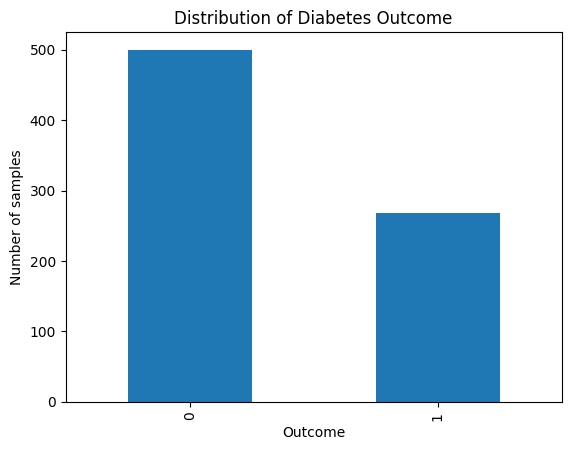

In [65]:
import matplotlib.pyplot as plt

y.value_counts().plot(kind='bar')
plt.xlabel("Outcome")
plt.ylabel("Number of samples")
plt.title("Distribution of Diabetes Outcome")
plt.show()

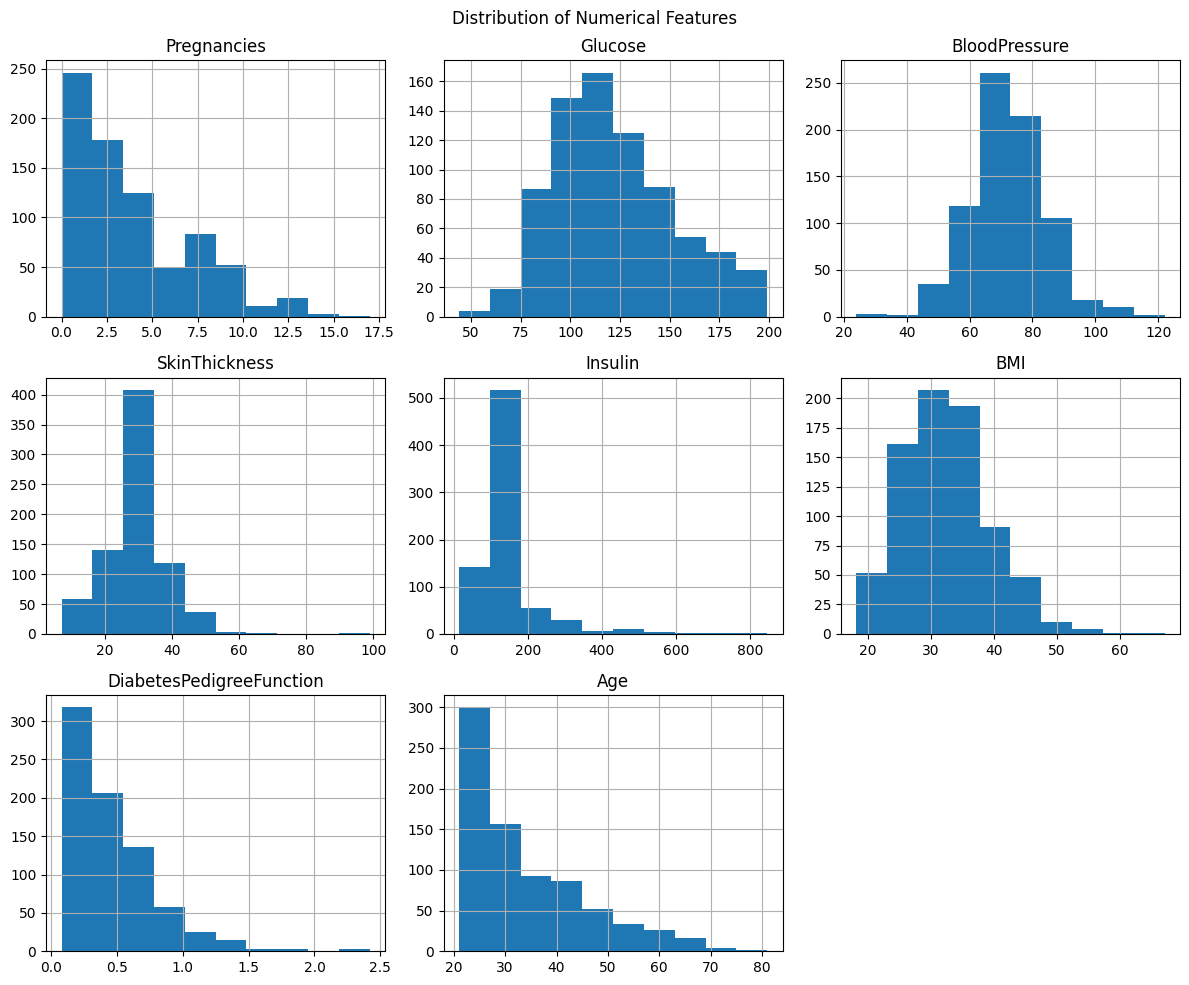

In [66]:
X.hist(figsize=(12, 10))
plt.suptitle("Distribution of Numerical Features")
plt.tight_layout()
plt.show()

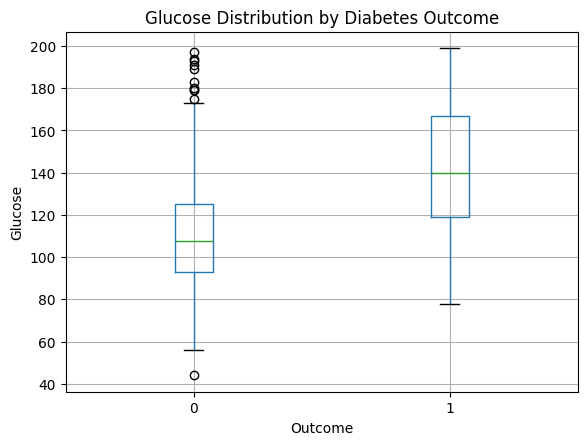

In [67]:
clean_df.boxplot(column='Glucose', by='Outcome')
plt.title('Glucose Distribution by Diabetes Outcome')
plt.suptitle('')
plt.xlabel('Outcome')
plt.ylabel('Glucose')
plt.show()

## Feature vs Target Analysis

I compared Glucose distributions for the two Outcome classes using a boxplot.

The Glucose values for Outcome = 1 are generally higher than those for Outcome = 0, with the median also being substantially higher. However, the two distributions still overlap, so Glucose alone does not completely distinguish the two outcome classes.

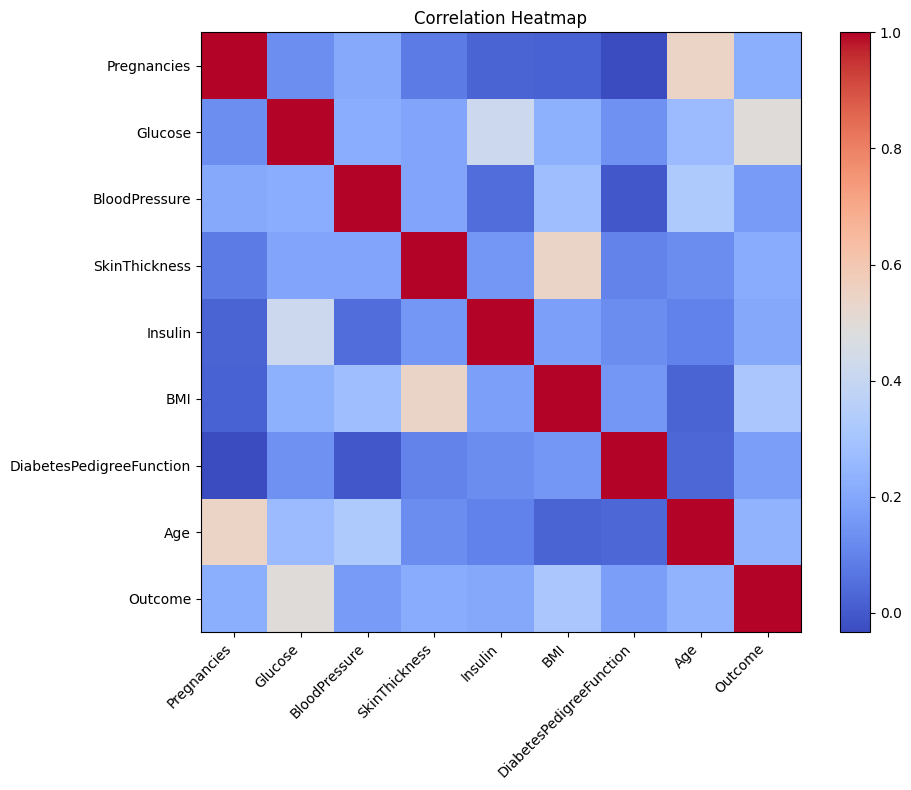

In [68]:
plt.figure(figsize=(10, 8))

corr = clean_df.corr()

plt.imshow(corr, cmap='coolwarm', interpolation='none')
plt.colorbar()

plt.xticks(range(len(corr.columns)), corr.columns, rotation=45, ha='right')
plt.yticks(range(len(corr.columns)), corr.columns)

plt.title("Correlation Heatmap")
plt.tight_layout()
plt.show()

## Correlation Analysis

A correlation heatmap was used to examine relationships between the numerical features and the target variable.

Glucose showed the strongest positive correlation with Outcome. Some features also showed relationships with each other, such as BMI and SkinThickness, but no feature was removed solely based on correlation because correlation alone is not sufficient evidence that a feature is unnecessary.

In [69]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [71]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(X_train_scaled)
print(X_test_scaled)

[[-0.85135507 -1.05642747 -0.82797293 ... -0.76981811  0.31079384
  -0.79216928]
 [ 0.35657564  0.14439907  0.47653222 ... -0.41783762 -0.11643851
   0.56103382]
 [-0.5493724  -0.55608308 -1.15409922 ...  0.35945263 -0.76486207
  -0.70759409]
 ...
 [-0.85135507 -0.82293342 -0.17572035 ...  0.82875995 -0.78607218
  -0.28471812]
 [ 1.86648903 -0.35594533 -0.17572035 ... -0.72582055 -1.01938346
   0.56103382]
 [ 0.05459296  0.74481233 -1.15409922 ... -0.43250348 -0.57700104
   0.30730824]]
[[ 0.96054099  1.24515673 -0.66490979 ... -0.74048641 -0.55579092
   0.56103382]
 [ 1.86648903 -1.79026591  2.75941625 ...  0.44744775 -0.58306107
   1.15306018]
 [-0.5493724   0.01097389  0.31346908 ...  0.50611117  0.01688223
  -0.6230189 ]
 ...
 [-0.5493724  -1.32327781 -1.64328866 ... -0.57916201  3.70138246
  -0.70759409]
 [ 0.05459296  2.07906404  0.47653222 ...  0.66743556 -0.64669142
  -0.20014293]
 [-0.85135507 -1.69019703  0.47653222 ...  0.11013312 -0.16794879
  -1.04589487]]


## Feature Scaling

The features have different numerical ranges, so StandardScaler was used to standardize them.

The data was first divided into training and testing sets. The scaler was fitted only on the training data and then used to transform both the training and testing data. This prevents information from the test set from influencing the scaling process.

After standardization, the training features have approximately a mean of 0 and a standard deviation of 1.

In [72]:
print(X_train_scaled.mean(axis=0))

[-6.94341436e-17 -1.09937394e-16  1.04874488e-15  3.87673968e-16
 -4.33963397e-18  8.38995901e-17 -1.09937394e-16 -1.08490849e-16]


In [73]:
print(X_train_scaled.std(axis=0))


[1. 1. 1. 1. 1. 1. 1. 1.]


## Categorical Variable Encoding

The dataset does not contain categorical predictor variables. All input features are numerical, so categorical encoding was not required.

In [74]:
print("Training shape:", X_train_scaled.shape)
print("Testing shape:", X_test_scaled.shape)

print("Missing values:")
print(clean_df.isnull().sum())

print("Duplicate rows:", clean_df.duplicated().sum())

Training shape: (614, 8)
Testing shape: (154, 8)
Missing values:
Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
Outcome                     0
dtype: int64
Duplicate rows: 0


In [75]:
print("Training mean:", X_train_scaled.mean(axis=0).round(2))
print("Training std:", X_train_scaled.std(axis=0).round(2))

Training mean: [-0. -0.  0.  0. -0.  0. -0. -0.]
Training std: [1. 1. 1. 1. 1. 1. 1. 1.]
